# Banking Customer Portfolio & Exposure Analytics
## 1. Objective

In this notebook, I explore customer age, nationality, occupation, income band, loyalty, fee structure, banking relationship, product holdings, and joining cohorts.

The file has 3,000 records and 2,940 unique client IDs. Some repeated IDs have different details, so I use all records for the segment analysis instead of guessing which row to remove.

## 2. Load and Briefly Validate Processed Data

I load the cleaned file from EDA 1 and check only the columns needed here.

In [1]:
# Import the packages used for data, charts, paths, and notebook output.
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:,.2f}".format)
sns.set_theme(style="whitegrid", palette="deep")

In [2]:
# Find the project folder and create the input and output paths.
cwd = Path.cwd().resolve()
project_root = (
    cwd
    if (cwd / "data/processed/banking_customers_clean.csv").exists()
    else cwd.parent
)
data_path = project_root / "data/processed/banking_customers_clean.csv"
figures_dir = project_root / "reports/figures/customer_segments"
tables_dir = project_root / "reports/tables"
figures_dir.mkdir(parents=True, exist_ok=True)

In [3]:
# Create output folders and load the cleaned customer file.
tables_dir.mkdir(parents=True, exist_ok=True)
df = pd.read_csv(data_path, parse_dates=["joined_bank"])
print(f"Loaded {len(df):,} records and {df.shape[1]} columns.")
display(df.head())

Loaded 3,000 records and 30 columns.


,client_id,name,age,location_id,joined_bank,banking_contact,nationality,occupation,fee_structure,loyalty_classification,estimated_income,superannuation_savings,amount_of_credit_cards,credit_card_balance,bank_loans,bank_deposits,checking_accounts,saving_accounts,foreign_currency_account,business_lending,properties_owned,risk_weighting,brid,genderid,iaid,join_year,join_month,join_month_name,join_decade,income_band
0,IND81288,Raymond Mills,24,34324,2019-05-06,Anthony Torres,American,Safety Technician IV,High,Jade,"75,384.77","17,677.95",1,484.54,"776,242.92","1,485,828.64","603,617.88","607,332.46","12,249.96","1,134,475.30",1,2,1,1,1,2019,5,May,2010,Low
1,IND65833,Julia Spencer,23,42205,2001-12-10,Jonathan Hawkins,African,Software Consultant,High,Jade,"289,834.31","17,398.92",1,"2,256.88","1,270,615.43","641,482.79","229,521.37","344,635.16","61,162.31","2,000,526.10",1,3,2,1,2,2001,12,December,2000,Mid
2,IND47499,Stephen Murray,27,7314,2010-01-25,Anthony Berry,European,Help Desk Operator,High,Gold,"169,935.23","42,825.90",2,"4,568.74","1,052,715.84","1,033,401.59","652,674.69","203,054.35","79,071.78","548,137.58",1,3,3,2,3,2010,1,January,2010,Mid
3,IND72498,Virginia Garza,40,34594,2019-03-28,Steve Diaz,American,Geologist II,Mid,Silver,"356,808.11","5,473.15",2,"4,205.00","121,195.06","1,048,157.49","1,048,157.49","234,685.02","57,513.65","1,148,402.29",0,4,4,1,4,2019,3,March,2010,High
4,IND60181,Melissa Sanders,46,41269,2012-07-20,Shawn Long,American,Assistant Professor,Mid,Platinum,"130,711.68","48,077.60",1,"3,779.49","1,048,301.95","487,782.53","446,644.25","128,351.45","30,012.14","1,674,412.12",0,3,1,2,5,2012,7,July,2010,Mid


In [4]:
# List the columns needed for this notebook.
required_columns = [
    "client_id",
    "age",
    "nationality",
    "occupation",
    "income_band",
    "loyalty_classification",
    "fee_structure",
    "brid",
    "amount_of_credit_cards",
    "properties_owned",
    "joined_bank",
    "join_year",
    "join_decade",
    "estimated_income",
    "bank_deposits",
    "bank_loans",
    "checking_accounts",
    "saving_accounts",
    "credit_card_balance",
    "business_lending",
]

In [5]:
# Check that every required column is available.
missing_columns = [
    column for column in required_columns if column not in df.columns
]
if missing_columns:
    raise ValueError(f"Required columns are missing: {missing_columns}")

In [6]:
# Create a short validation summary for the processed file.
validation = pd.Series(
    {
        "rows": len(df),
        "columns": df.shape[1],
        "unique_client_ids": df["client_id"].nunique(),
        "missing_analysis_values": int(
            df[required_columns].isna().sum().sum()
        ),
        "joined_bank_is_datetime": pd.api.types.is_datetime64_any_dtype(
            df["joined_bank"]
        ),
    }
)

In [7]:
# Display the validation results.
display(validation.to_frame("result"))

,result
rows,3000
columns,30
unique_client_ids,2940
missing_analysis_values,0
joined_bank_is_datetime,True


In [8]:
# Set the category order and create neutral banking-relationship labels.
income_order = ["Low", "Mid", "High"]
age_order = ["Under 25", "25-34", "35-44", "45-54", "55-64", "65 and above"]
loyalty_order = [
    value
    for value in ["Jade", "Silver", "Gold", "Platinum"]
    if value in df["loyalty_classification"].unique()
]

In [9]:
# Finish the category orders used in the charts.
fee_order = [
    value
    for value in ["Low", "Mid", "High"]
    if value in df["fee_structure"].unique()
]
df["banking_relationship"] = "BR " + df["brid"].astype(str)
br_order = sorted(
    df["banking_relationship"].unique(),
    key=lambda value: int(value.split()[-1]),
)

In [10]:
# Create the six required age groups.
df["age_group"] = pd.cut(
    df["age"],
    bins=[-np.inf, 24, 34, 44, 54, 64, np.inf],
    labels=age_order,
    ordered=True,
)
print("Analysis categories prepared.")

Analysis categories prepared.


## 3. Customer Overview

I start with a small KPI table and the overall age distribution.

In [11]:
# Calculate the requested customer KPIs.
kpi_values = {
    "Total unique customers": df["client_id"].nunique(),
    "Median age": df["age"].median(),
    "Median estimated income": df["estimated_income"].median(),
    "Most common income band": df["income_band"].mode().iloc[0],
    "Most common nationality": df["nationality"].mode().iloc[0],
    "Most common occupation": df["occupation"].mode().iloc[0],
    "Most common loyalty classification": df["loyalty_classification"]
    .mode()
    .iloc[0],
    "Most common fee structure": df["fee_structure"].mode().iloc[0],
    "Median number of credit cards": df["amount_of_credit_cards"].median(),
    "Median properties owned": df["properties_owned"].median(),
}

In [12]:
# Turn the KPI values into a two-column table.
customer_kpis = pd.DataFrame(
    {"kpi": kpi_values.keys(), "value": kpi_values.values()}
)
display(customer_kpis)

,kpi,value
0,Total unique customers,2940
1,Median age,51.00
2,Median estimated income,"142,313.48"
3,Most common income band,Mid
4,Most common nationality,European
5,Most common occupation,Associate Professor
6,Most common loyalty classification,Jade
7,Most common fee structure,High
8,Median number of credit cards,1.00
9,Median properties owned,2.00


**Observation:** The dataset contains **2,940 unique client IDs**. Median age is **51**, median estimated income is **142,313.48**, and the typical record has **1 credit card** and **2 properties**.

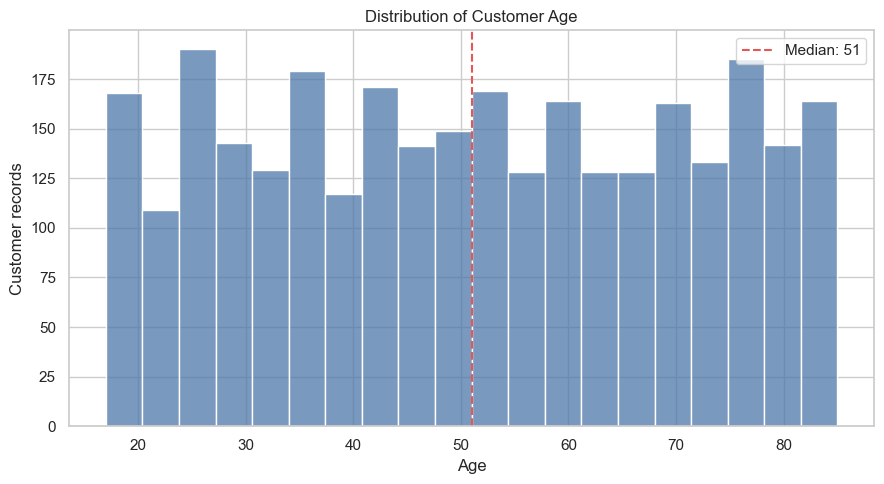

In [13]:
# Create, format, save, and show this customer chart.
fig, ax = plt.subplots(figsize=(9, 5))
sns.histplot(
    data=df, x="age", bins=20, color="#4C78A8", edgecolor="white", ax=ax
)
ax.axvline(
    df["age"].median(),
    color="#E45756",
    linestyle="--",
    label=f"Median: {df['age'].median():.0f}",
)

ax.set(
    title="Distribution of Customer Age",
    xlabel="Age",
    ylabel="Customer records",
)
ax.legend()
plt.tight_layout()
fig.savefig(
    figures_dir / "customer_age_distribution.png", dpi=300, bbox_inches="tight"
)

plt.show()

## 4. Age and Demographic Analysis

The age groups are kept in a fixed order so the table and chart are easy to compare.

In [14]:
# Calculate customer-record counts and percentages for each age group.
age_group_summary = (
    df["age_group"]
    .value_counts(sort=False)
    .rename_axis("age_group")
    .reset_index(name="customer_count")
)
age_group_summary["percentage"] = (
    age_group_summary["customer_count"] / len(df) * 100
)
display(age_group_summary)

,age_group,customer_count,percentage
0,Under 25,322,10.73
1,25-34,459,15.30
2,35-44,425,14.17
3,45-54,459,15.30
4,55-64,420,14.00
5,65 and above,915,30.50


**Observation:** The largest age group is **65 and above**, with **915 records (30.5%)**. This describes the recorded portfolio only; it does not explain customer needs or behaviour.

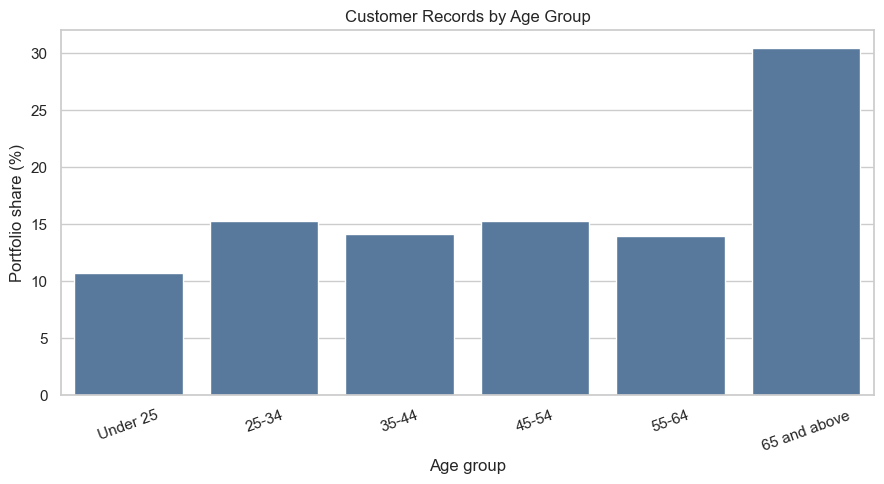

In [15]:
# Create, format, save, and show this customer chart.
fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(
    data=age_group_summary,
    x="age_group",
    y="percentage",
    color="#4C78A8",
    ax=ax,
)

ax.set(
    title="Customer Records by Age Group",
    xlabel="Age group",
    ylabel="Portfolio share (%)",
)
ax.tick_params(axis="x", rotation=20)
plt.tight_layout()
fig.savefig(
    figures_dir / "age_group_percentage.png", dpi=300, bbox_inches="tight"
)

plt.show()

## 5. Nationality and Occupation Analysis

All nationality categories are shown. For occupation, I show only the top 15 because plotting all 195 occupations would be difficult to read.

In [16]:
# Calculate nationality counts and percentages.
nationality_summary = (
    df["nationality"]
    .value_counts()
    .rename_axis("nationality")
    .reset_index(name="customer_count")
)
nationality_summary["percentage"] = (
    nationality_summary["customer_count"] / len(df) * 100
)
display(nationality_summary)

,nationality,customer_count,percentage
0,European,1309,43.63
1,Asian,754,25.13
2,American,507,16.90
3,Australian,254,8.47
4,African,176,5.87


**Observation:** European is the largest nationality group with **1,309 records (43.6%)**. Nationality is descriptive and should not be used as a cause of financial behaviour.

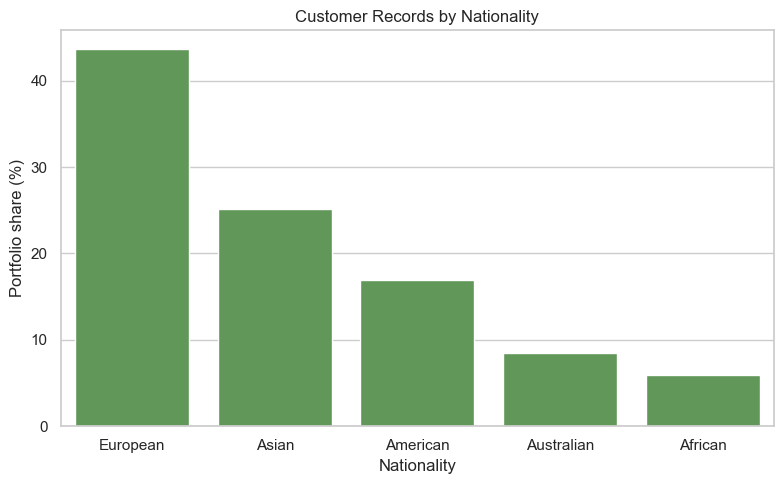

In [17]:
# Create, format, save, and show this chart.
fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(
    data=nationality_summary,
    x="nationality",
    y="percentage",
    color="#59A14F",
    ax=ax,
)

ax.set(
    title="Customer Records by Nationality",
    xlabel="Nationality",
    ylabel="Portfolio share (%)",
)
plt.tight_layout()
fig.savefig(
    figures_dir / "nationality_percentage.png", dpi=300, bbox_inches="tight"
)
plt.show()

In [18]:
# Count unique occupations and select the 15 most common.
unique_occupations = df["occupation"].nunique()
top_occupations = (
    df["occupation"]
    .value_counts()
    .head(15)
    .sort_values()
    .rename_axis("occupation")
    .reset_index(name="customer_count")
)
print(f"Number of unique occupations: {unique_occupations}")

Number of unique occupations: 195


,occupation,customer_count
13,Structural Analysis Engineer,28
14,Associate Professor,28
12,Recruiter,25
10,Human Resources Manager,24
11,Account Coordinator,24
5,Internal Auditor,23
6,Assistant Professor,23
7,Database Administrator III,23
8,Dental Hygienist,23
9,Database Administrator II,23


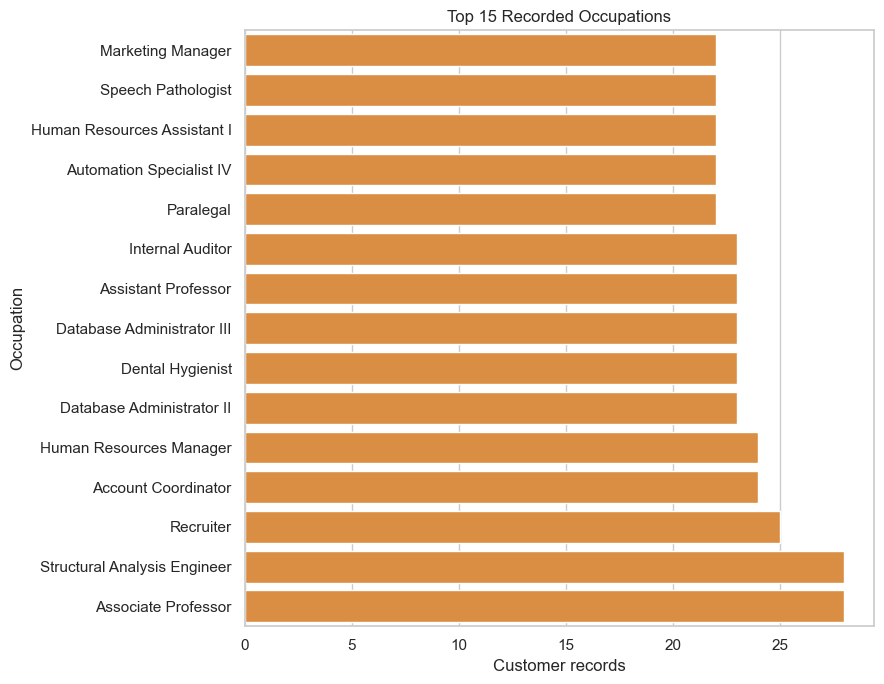

In [19]:
# Display the occupation table and create the readable horizontal chart.
display(top_occupations.sort_values("customer_count", ascending=False))
fig, ax = plt.subplots(figsize=(9, 7))
sns.barplot(
    data=top_occupations,
    x="customer_count",
    y="occupation",
    color="#F28E2B",
    ax=ax,
)

ax.set(
    title="Top 15 Recorded Occupations",
    xlabel="Customer records",
    ylabel="Occupation",
)
plt.tight_layout()
fig.savefig(
    figures_dir / "top_15_occupations.png", dpi=300, bbox_inches="tight"
)
plt.show()

## 6. Income-Band Analysis

The Low, Mid, and High bands were created in EDA 1 for this project. They are not official banking thresholds.

In [20]:
# Calculate counts and percentages for Low, Mid, and High income bands.
income_band_summary = (
    df["income_band"]
    .value_counts()
    .reindex(income_order, fill_value=0)
    .rename_axis("income_band")
    .reset_index(name="customer_count")
)
income_band_summary["percentage"] = (
    income_band_summary["customer_count"] / len(df) * 100
)

**Observation:** Mid income is the largest band with **1,517 records (50.6%)**, followed by Low with 1,027 and High with 456. These bands are project-specific.

,income_band,customer_count,percentage
0,Low,1027,34.23
1,Mid,1517,50.57
2,High,456,15.20


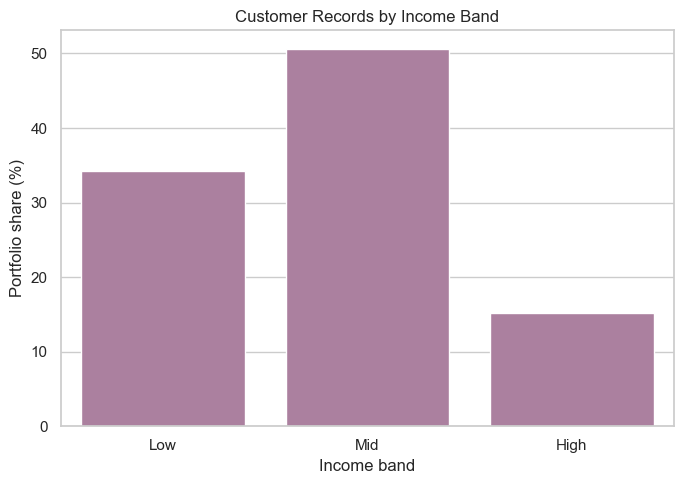

In [21]:
# Display the income-band table and create its percentage chart.
display(income_band_summary)
fig, ax = plt.subplots(figsize=(7, 5))
sns.barplot(
    data=income_band_summary,
    x="income_band",
    y="percentage",
    order=income_order,
    color="#B279A2",
    ax=ax,
)

ax.set(
    title="Customer Records by Income Band",
    xlabel="Income band",
    ylabel="Portfolio share (%)",
)
plt.tight_layout()
fig.savefig(
    figures_dir / "income_band_percentage.png", dpi=300, bbox_inches="tight"
)
plt.show()

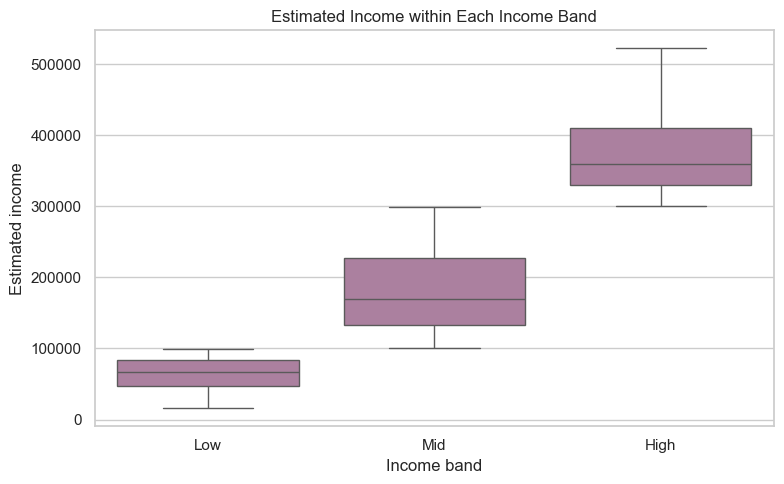

In [22]:
# Create, format, save, and show this chart.
fig, ax = plt.subplots(figsize=(8, 5))
sns.boxplot(
    data=df,
    x="income_band",
    y="estimated_income",
    order=income_order,
    color="#B279A2",
    ax=ax,
)

ax.set(
    title="Estimated Income within Each Income Band",
    xlabel="Income band",
    ylabel="Estimated income",
)
plt.tight_layout()

fig.savefig(
    figures_dir / "income_by_income_band_boxplot.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()

## 7. Loyalty and Fee-Structure Analysis

This section compares the recorded loyalty and fee categories.

In [23]:
# Calculate the loyalty summary.
loyalty_summary = (
    df["loyalty_classification"]
    .value_counts()
    .reindex(loyalty_order, fill_value=0)
    .rename_axis("loyalty_classification")
    .reset_index(name="customer_count")
)
loyalty_summary["percentage"] = (
    loyalty_summary["customer_count"] / len(df) * 100
)

**Observation:** Jade is the largest loyalty group with **1,331 records (44.4%)**, while High is the most common fee structure with **1,476 records (49.2%)**. The business rules behind these labels are not provided.

In [24]:
# Calculate the fee-structure summary.
fee_summary = (
    df["fee_structure"]
    .value_counts()
    .reindex(fee_order, fill_value=0)
    .rename_axis("fee_structure")
    .reset_index(name="customer_count")
)
fee_summary["percentage"] = fee_summary["customer_count"] / len(df) * 100
display(loyalty_summary)
display(fee_summary)

,loyalty_classification,customer_count,percentage
0,Jade,1331,44.37
1,Silver,767,25.57
2,Gold,585,19.50
3,Platinum,317,10.57


,fee_structure,customer_count,percentage
0,Low,562,18.73
1,Mid,962,32.07
2,High,1476,49.20


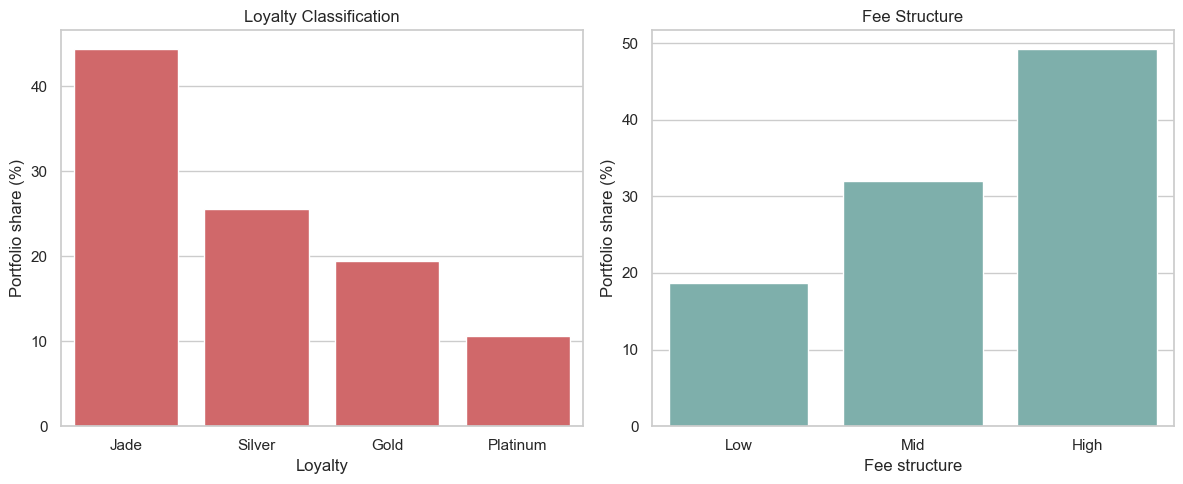

In [25]:
# Create, format, save, and show the two side-by-side charts.
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.barplot(
    data=loyalty_summary,
    x="loyalty_classification",
    y="percentage",
    order=loyalty_order,
    color="#E15759",
    ax=axes[0],
)

axes[0].set(
    title="Loyalty Classification",
    xlabel="Loyalty",
    ylabel="Portfolio share (%)",
)

sns.barplot(
    data=fee_summary,
    x="fee_structure",
    y="percentage",
    order=fee_order,
    color="#76B7B2",
    ax=axes[1],
)

axes[1].set(
    title="Fee Structure", xlabel="Fee structure", ylabel="Portfolio share (%)"
)
plt.tight_layout()
fig.savefig(
    figures_dir / "loyalty_and_fee_structure.png", dpi=300, bbox_inches="tight"
)
plt.show()

## 8. Banking-Relationship Analysis

`brid` is a category code. Since its real labels are not provided, I use neutral names: BR 1, BR 2, BR 3, and BR 4.

In [26]:
# Calculate counts and percentages for the neutral BR groups.
banking_relationship_summary = (
    df["banking_relationship"]
    .value_counts()
    .reindex(br_order, fill_value=0)
    .rename_axis("banking_relationship")
    .reset_index(name="customer_count")
)
banking_relationship_summary["percentage"] = (
    banking_relationship_summary["customer_count"] / len(df) * 100
)

**Observation:** BR 3 is the largest relationship group with **1,352 records (45.1%)**. BR labels remain neutral because their real meanings are not available.

,banking_relationship,customer_count,percentage
0,BR 1,660,22.00
1,BR 2,495,16.50
2,BR 3,1352,45.07
3,BR 4,493,16.43


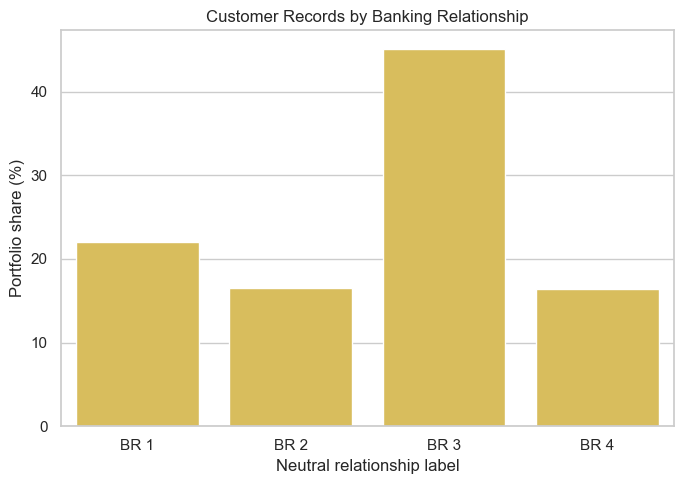

In [27]:
# Display the BR table and create its chart.
display(banking_relationship_summary)
fig, ax = plt.subplots(figsize=(7, 5))
sns.barplot(
    data=banking_relationship_summary,
    x="banking_relationship",
    y="percentage",
    order=br_order,
    color="#EDC948",
    ax=ax,
)

ax.set(
    title="Customer Records by Banking Relationship",
    xlabel="Neutral relationship label",
    ylabel="Portfolio share (%)",
)
plt.tight_layout()

fig.savefig(
    figures_dir / "banking_relationship_percentage.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()

## 9. Product-Holding Behaviour

I compare the recorded number of credit cards and properties owned.

In [28]:
# Calculate the credit-card holding summary.
credit_card_summary = (
    df["amount_of_credit_cards"]
    .value_counts()
    .sort_index()
    .rename_axis("credit_cards")
    .reset_index(name="customer_count")
)
credit_card_summary["percentage"] = (
    credit_card_summary["customer_count"] / len(df) * 100
)

**Observation:** **1,922 records (64.1%)** show one credit card. Property ownership is more evenly spread, with two properties being the most common at **777 records (25.9%)**.

In [29]:
# Calculate the properties-owned summary.
property_summary = (
    df["properties_owned"]
    .value_counts()
    .sort_index()
    .rename_axis("properties_owned")
    .reset_index(name="customer_count")
)
property_summary["percentage"] = (
    property_summary["customer_count"] / len(df) * 100
)

In [30]:
# Display both product-holding tables.
display(credit_card_summary)
display(property_summary)

,credit_cards,customer_count,percentage
0,1,1922,64.07
1,2,765,25.50
2,3,313,10.43


,properties_owned,customer_count,percentage
0,0,705,23.50
1,1,776,25.87
2,2,777,25.90
3,3,742,24.73


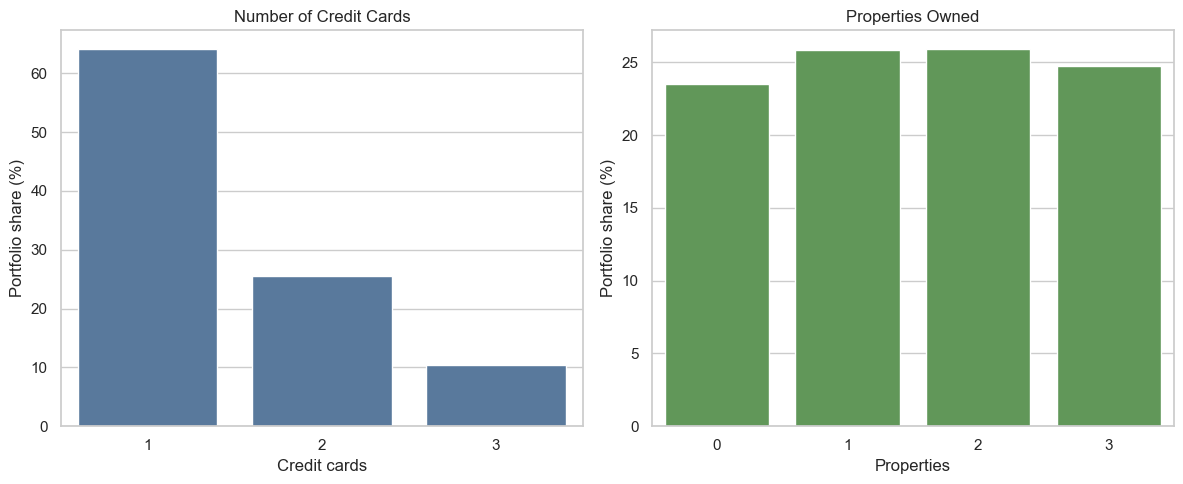

In [31]:
# Create, format, save, and show the two side-by-side charts.
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.barplot(
    data=credit_card_summary,
    x="credit_cards",
    y="percentage",
    color="#4E79A7",
    ax=axes[0],
)

axes[0].set(
    title="Number of Credit Cards",
    xlabel="Credit cards",
    ylabel="Portfolio share (%)",
)

sns.barplot(
    data=property_summary,
    x="properties_owned",
    y="percentage",
    color="#59A14F",
    ax=axes[1],
)
axes[1].set(
    title="Properties Owned", xlabel="Properties", ylabel="Portfolio share (%)"
)

plt.tight_layout()
fig.savefig(
    figures_dir / "product_holding_behaviour.png", dpi=300, bbox_inches="tight"
)
plt.show()

### Normalized Segment Comparisons

Each row adds to 100%. This makes groups of different sizes easier to compare.

In [32]:
# Create a small helper that converts a cross-tab to row percentages.
def normalized_table(
    row_column, column_column, row_order=None, column_order=None
):
    table = (
        pd.crosstab(df[row_column], df[column_column], normalize="index") * 100
    )
    if row_order is not None:
        table = table.reindex(row_order, fill_value=0)
    if column_order is not None:
        table = table.reindex(columns=column_order, fill_value=0)
    return table

In [33]:
# Calculate the six required normalized comparison tables.
segment_tables = {
    "Income band vs age group": normalized_table(
        "age_group", "income_band", age_order, income_order
    ),
    "Income band vs loyalty": normalized_table(
        "loyalty_classification", "income_band", loyalty_order, income_order
    ),
    "Income band vs fee structure": normalized_table(
        "fee_structure", "income_band", fee_order, income_order
    ),
    "Loyalty vs banking relationship": normalized_table(
        "banking_relationship",
        "loyalty_classification",
        br_order,
        loyalty_order,
    ),
    "Income band vs credit-card holdings": normalized_table(
        "amount_of_credit_cards", "income_band", None, income_order
    ),
    "Income band vs properties owned": normalized_table(
        "properties_owned", "income_band", None, income_order
    ),
}

In [34]:
# Display each normalized table.
for title, table in segment_tables.items():
    print(title)
    display(table.round(2))

Income band vs age group


income_band,Low,Mid,High
age_group,,,
Under 25,34.16,51.24,14.60
25-34,34.42,51.20,14.38
35-44,32.94,50.12,16.94
45-54,33.55,47.49,18.95
55-64,35.95,51.19,12.86
65 and above,34.32,51.48,14.21


Income band vs loyalty


income_band,Low,Mid,High
loyalty_classification,,,
Jade,32.76,51.77,15.48
Silver,35.72,47.20,17.08
Gold,35.21,51.11,13.68
Platinum,35.02,52.68,12.30


Income band vs fee structure


...

loyalty_classification,Jade,Silver,Gold,Platinum
banking_relationship,,,,
BR 1,46.21,25.61,17.73,10.45
BR 2,46.06,25.25,17.37,11.31
BR 3,42.60,26.04,21.08,10.28
BR 4,45.03,24.54,19.68,10.75


Income band vs credit-card holdings


income_band,Low,Mid,High
amount_of_credit_cards,,,
1,33.30,51.40,15.30
2,33.46,48.76,17.78
3,41.85,49.84,8.31


Income band vs properties owned


income_band,Low,Mid,High
properties_owned,,,
0,32.77,50.50,16.74
1,34.79,50.64,14.56
2,34.88,50.71,14.41
3,34.37,50.40,15.23


In [35]:
# Create and save one readable heatmap for each normalized comparison.
heatmap_files = {
    "Income band vs age group": "income_band_vs_age_group.png",
    "Income band vs loyalty": "income_band_vs_loyalty.png",
    "Income band vs fee structure": "income_band_vs_fee_structure.png",
    "Loyalty vs banking relationship": "loyalty_vs_banking_relationship.png",
    "Income band vs credit-card holdings": "income_band_vs_credit_cards.png",
    "Income band vs properties owned": "income_band_vs_properties.png",
}

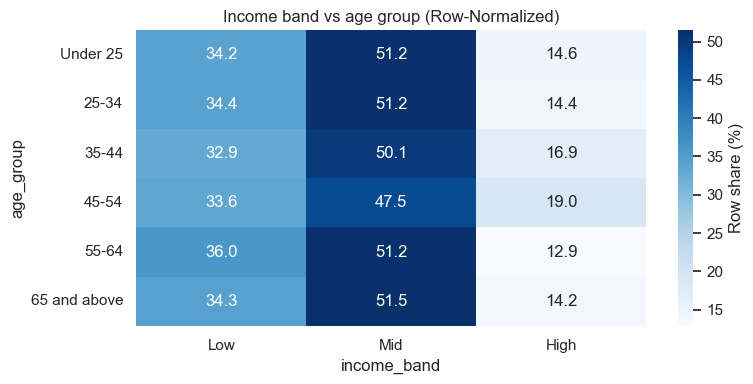

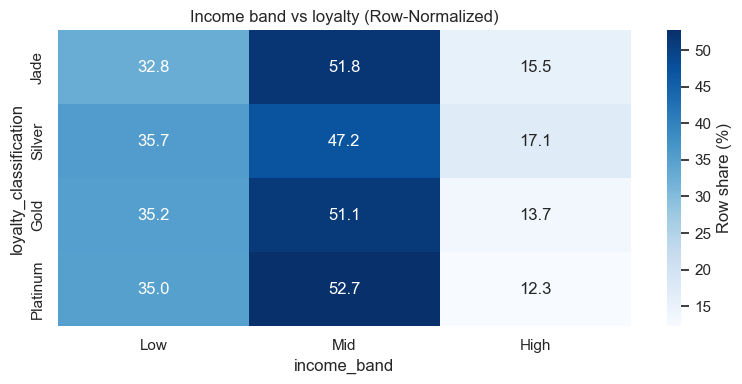

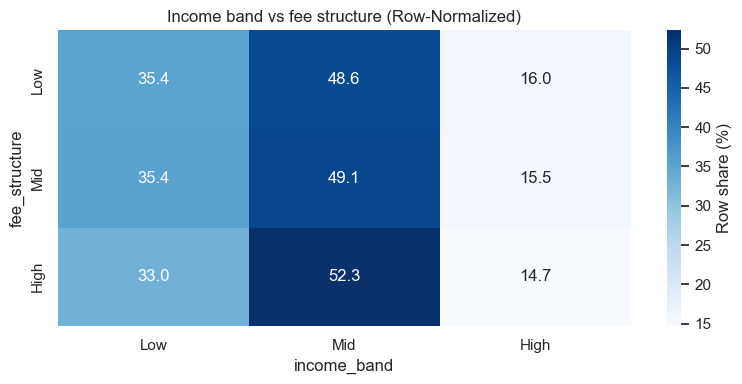

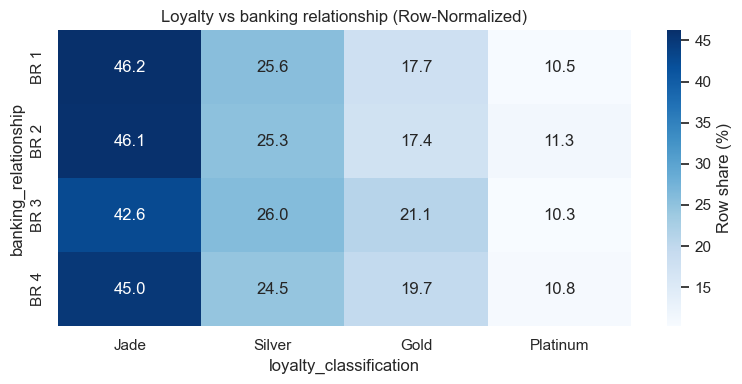

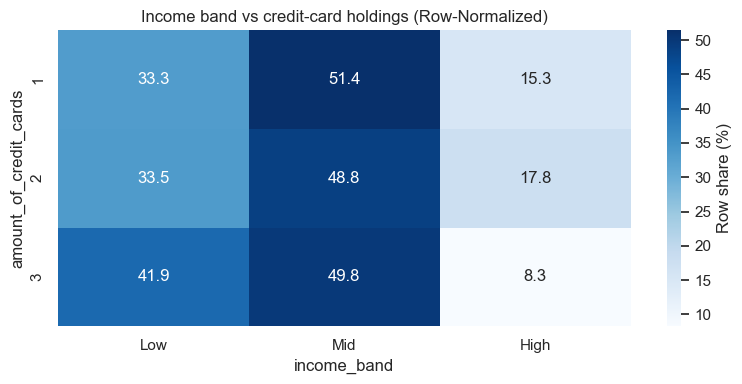

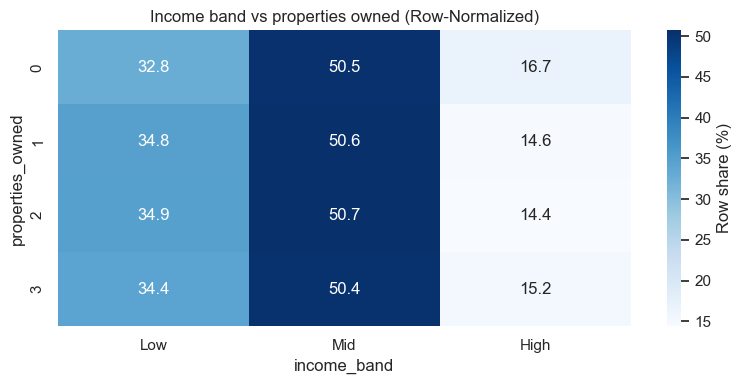

In [36]:
# Display each normalized table.
for title, table in segment_tables.items():
    fig, ax = plt.subplots(figsize=(8, max(4, len(table) * 0.65)))
    sns.heatmap(
        table,
        annot=True,
        fmt=".1f",
        cmap="Blues",
        cbar_kws={"label": "Row share (%)"},
        ax=ax,
    )
    ax.set_title(f"{title} (Row-Normalized)")
    ax.set_xlabel(table.columns.name or "Segment")
    ax.set_ylabel(table.index.name or "Segment")
    plt.tight_layout()
    fig.savefig(
        figures_dir / heatmap_files[title], dpi=300, bbox_inches="tight"
    )
    plt.show()

### Median Financial Values by Segment

I use medians because the financial columns are skewed. These values describe recorded amounts, not profit.

In [37]:
# List the financial values used for median comparisons.
financial_columns = [
    "estimated_income",
    "bank_deposits",
    "bank_loans",
    "checking_accounts",
    "saving_accounts",
    "credit_card_balance",
    "business_lending",
]

In [38]:
# Calculate median financial values by income and loyalty group.
median_by_income = (
    df.groupby("income_band", observed=False)[financial_columns]
    .median()
    .reindex(income_order)
)
median_by_loyalty = (
    df.groupby("loyalty_classification", observed=False)[financial_columns]
    .median()
    .reindex(loyalty_order)
)

In [39]:
# Display the two median financial tables.
print("Median financial values by income band")
display(median_by_income)
print("Median financial values by loyalty classification")
display(median_by_loyalty)

Median financial values by income band


,estimated_income,bank_deposits,bank_loans,checking_accounts,saving_accounts,credit_card_balance,business_lending
income_band,,,,,,,
Low,"66,543.57","336,806.30","333,302.25","172,780.15","117,057.07","1,937.10","504,091.88"
Mid,"170,196.21","519,994.31","530,674.17","264,739.81","177,661.92","2,810.30","779,158.77"
High,"359,337.98","735,655.26","733,433.21","361,846.57","258,972.86","3,858.45","1,103,762.75"


Median financial values by loyalty classification


,estimated_income,bank_deposits,bank_loans,checking_accounts,saving_accounts,credit_card_balance,business_lending
loyalty_classification,,,,,,,
Jade,"144,947.04","490,931.68","496,902.60","253,013.24","168,784.05","2,559.60","728,283.30"
Silver,"141,689.81","452,216.52","479,104.12","246,221.16","159,495.26","2,552.68","696,597.14"
Gold,"139,310.32","442,275.47","462,978.43","228,066.56","168,442.58","2,743.23","707,174.79"
Platinum,"136,956.20","435,466.02","441,663.74","214,039.18","156,853.99","2,498.65","702,795.98"


## 10. Joining-Cohort Analysis

This section shows when the customer records joined the bank. It does not measure retention, revenue, or growth.

In [40]:
# Calculate the joining-year summary.
joining_year_summary = (
    df["join_year"]
    .value_counts()
    .sort_index()
    .rename_axis("join_year")
    .reset_index(name="customer_count")
)
joining_year_summary["percentage"] = (
    joining_year_summary["customer_count"] / len(df) * 100
)

**Observation:** The 2010s contain the largest joining cohort with **1,169 records (39.0%)**. This is a count of recorded join dates, not retention or revenue growth.

In [41]:
# Calculate the joining-decade summary.
joining_cohort_summary = (
    df["join_decade"]
    .value_counts()
    .sort_index()
    .rename_axis("join_decade")
    .reset_index(name="customer_count")
)
joining_cohort_summary["percentage"] = (
    joining_cohort_summary["customer_count"] / len(df) * 100
)

In [42]:
# Display the joining summaries.
display(joining_year_summary)
display(joining_cohort_summary)

,join_year,customer_count,percentage
0,1995,97,3.23
1,1996,109,3.63
2,1999,101,3.37
3,2000,99,3.30
4,2001,106,3.53
5,2002,110,3.67
6,2003,98,3.27
7,2004,106,3.53
8,2005,119,3.97
9,2006,112,3.73


,join_decade,customer_count,percentage
0,1990,307,10.23
1,2000,1082,36.07
2,2010,1169,38.97
3,2020,442,14.73


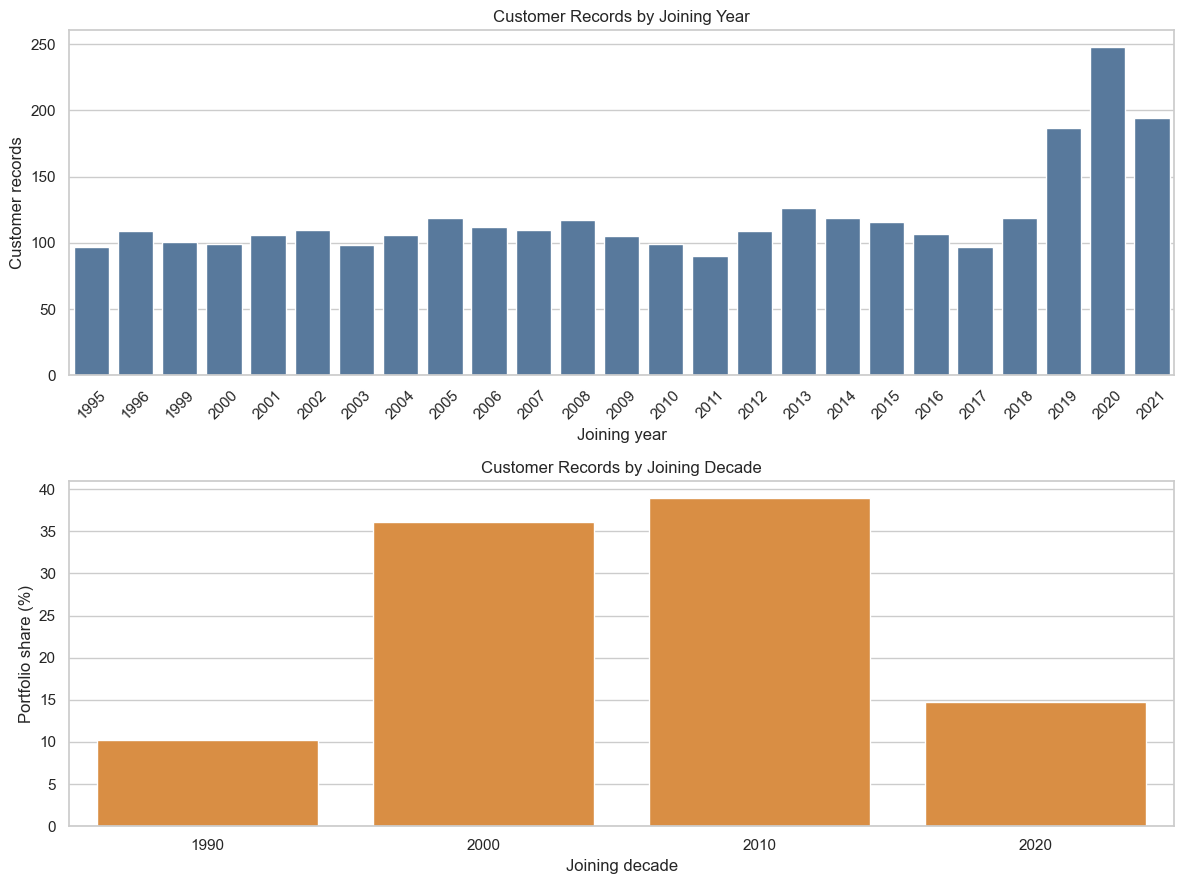

In [43]:
# Create, format, save, and show joining year and decade charts.
fig, axes = plt.subplots(2, 1, figsize=(12, 9))
sns.barplot(
    data=joining_year_summary,
    x="join_year",
    y="customer_count",
    color="#4C78A8",
    ax=axes[0],
)

axes[0].set(
    title="Customer Records by Joining Year",
    xlabel="Joining year",
    ylabel="Customer records",
)
axes[0].tick_params(axis="x", rotation=45)

sns.barplot(
    data=joining_cohort_summary,
    x="join_decade",
    y="percentage",
    color="#F28E2B",
    ax=axes[1],
)

axes[1].set(
    title="Customer Records by Joining Decade",
    xlabel="Joining decade",
    ylabel="Portfolio share (%)",
)
plt.tight_layout()
fig.savefig(
    figures_dir / "joining_year_and_decade.png", dpi=300, bbox_inches="tight"
)
plt.show()

income_band,Low,Mid,High
join_decade,,,
1990,32.57,53.42,14.01
2000,35.40,48.06,16.54
2010,33.36,51.58,15.06
2020,34.84,52.04,13.12


loyalty_classification,Jade,Silver,Gold,Platinum
join_decade,,,,
1990,48.53,24.76,16.61,10.10
2000,40.94,27.17,20.33,11.55
2010,44.57,26.43,19.33,9.67
2020,49.32,19.91,19.91,10.86


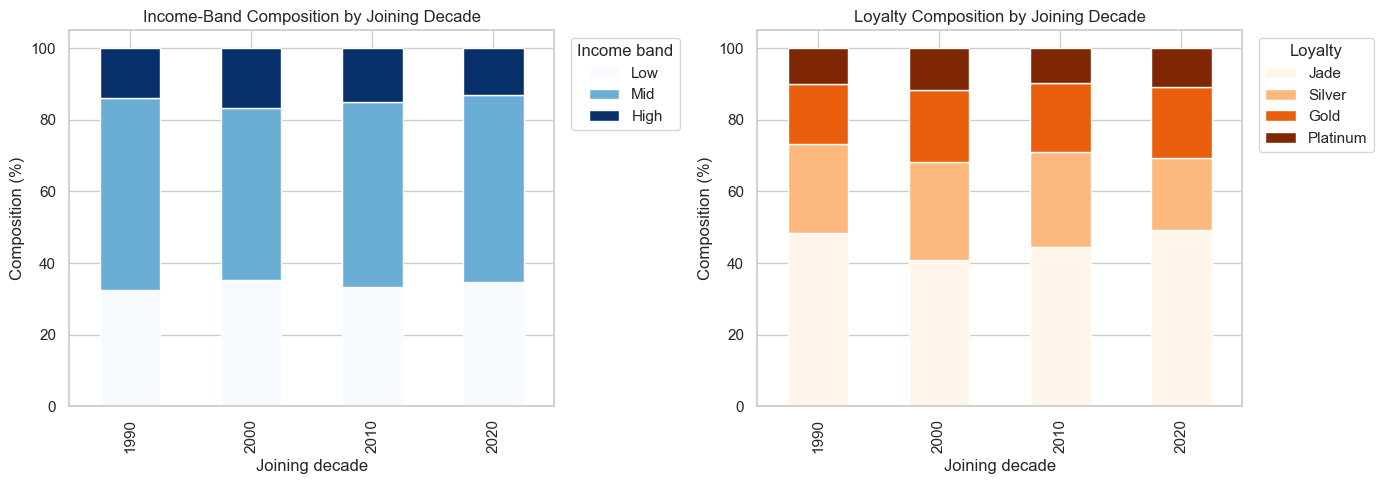

In [44]:
# Calculate decade composition and create both 100% stacked charts.
decade_income = normalized_table(
    "join_decade", "income_band", None, income_order
)
decade_loyalty = normalized_table(
    "join_decade", "loyalty_classification", None, loyalty_order
)
display(decade_income.round(2))
display(decade_loyalty.round(2))
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
decade_income.plot(kind="bar", stacked=True, ax=axes[0], colormap="Blues")

axes[0].set(
    title="Income-Band Composition by Joining Decade",
    xlabel="Joining decade",
    ylabel="Composition (%)",
)
axes[0].legend(title="Income band", bbox_to_anchor=(1.02, 1), loc="upper left")
decade_loyalty.plot(kind="bar", stacked=True, ax=axes[1], colormap="Oranges")

axes[1].set(
    title="Loyalty Composition by Joining Decade",
    xlabel="Joining decade",
    ylabel="Composition (%)",
)
axes[1].legend(title="Loyalty", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()

fig.savefig(
    figures_dir / "decade_segment_composition.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()

## Export Summary Tables

In [45]:
# Export the six requested summary tables.
customer_kpis.to_csv(tables_dir / "customer_kpis.csv", index=False)
age_group_summary.to_csv(tables_dir / "age_group_summary.csv", index=False)
income_band_summary.to_csv(tables_dir / "income_band_summary.csv", index=False)
loyalty_summary.to_csv(tables_dir / "loyalty_summary.csv", index=False)
banking_relationship_summary.to_csv(
    tables_dir / "banking_relationship_summary.csv", index=False
)
joining_cohort_summary.to_csv(
    tables_dir / "joining_cohort_summary.csv", index=False
)

In [46]:
# Confirm that the tables were exported.
print("Six customer-segment tables exported successfully.")

Six customer-segment tables exported successfully.


## 11. Final Insights and Limitations

These final points summarize the main results from the notebook.

In [47]:
# Calculate the values used in the final insights.
unique_customer_count = df["client_id"].nunique()
record_count = len(df)
median_age = df["age"].median()
older_share = (df["age_group"] == "65 and above").mean() * 100
mid_share = (df["income_band"] == "Mid").mean() * 100
european_share = (df["nationality"] == "European").mean() * 100
jade_share = (df["loyalty_classification"] == "Jade").mean() * 100
br3_share = (df["banking_relationship"] == "BR 3").mean() * 100
one_card_share = (df["amount_of_credit_cards"] == 1).mean() * 100
recent_share = (df["join_decade"] == 2010).mean() * 100

In [48]:
# Collect the final financial medians.
high_deposit_median = median_by_income.loc["High", "bank_deposits"]
low_deposit_median = median_by_income.loc["Low", "bank_deposits"]

In [49]:
# Build the eight final insights using calculated values.
insights = [
    f"1. **Customer base:** {record_count:,} records represent {unique_customer_count:,} unique client IDs. Segment results describe records because repeated IDs conflict and cannot be safely deduplicated.",
    f"2. **Age profile:** Median age is {median_age:.0f}, while {older_share:.1f}% of records are age 65 or above. This indicates an older recorded profile, but age alone does not explain product needs.",
    f"3. **Income mix:** Mid income is the largest band at {mid_share:.1f}% of records. The thresholds are project-specific and are not official banking classifications.",
    f"4. **Nationality mix:** European is the largest recorded nationality at {european_share:.1f}%. Nationality labels are broad and should not be treated as explanations of behaviour.",
    f"5. **Loyalty mix:** Jade accounts for {jade_share:.1f}% of records. The dataset does not document the business rules or value hierarchy behind loyalty labels.",
    f"6. **Banking relationship:** BR 3 represents {br3_share:.1f}% of records. Neutral labels are used because BR meanings are not verified.",
    f"7. **Product holding:** {one_card_share:.1f}% of records show one credit card. Counts show holdings only and do not measure usage, profitability, or satisfaction.",
    f"8. **Financial and cohort pattern:** Median bank deposits rise from {low_deposit_median:,.2f} in Low income to {high_deposit_median:,.2f} in High income, and {recent_share:.1f}% of records joined in the 2010s. These are descriptive associations, not causal, retention, or revenue-growth evidence.",
]

In [50]:
# Display the final insights as readable Markdown.
display(Markdown("\n\n".join(insights)))

1. **Customer base:** 3,000 records represent 2,940 unique client IDs. Segment results describe records because repeated IDs conflict and cannot be safely deduplicated.

2. **Age profile:** Median age is 51, while 30.5% of records are age 65 or above. This indicates an older recorded profile, but age alone does not explain product needs.

3. **Income mix:** Mid income is the largest band at 50.6% of records. The thresholds are project-specific and are not official banking classifications.

4. **Nationality mix:** European is the largest recorded nationality at 43.6%. Nationality labels are broad and should not be treated as explanations of behaviour.

5. **Loyalty mix:** Jade accounts for 44.4% of records. The dataset does not document the business rules or value hierarchy behind loyalty labels.

6. **Banking relationship:** BR 3 represents 45.1% of records. Neutral labels are used because BR meanings are not verified.

7. **Product holding:** 64.1% of records show one credit card. Counts show holdings only and do not measure usage, profitability, or satisfaction.

8. **Financial and cohort pattern:** Median bank deposits rise from 336,806.30 in Low income to 735,655.26 in High income, and 39.0% of records joined in the 2010s. These are descriptive associations, not causal, retention, or revenue-growth evidence.

### Remaining limitations

- The repeated client IDs have different details, so the segment percentages are based on records.
- The income bands are project-specific.
- The real meanings of the BR codes are not provided.
- Loyalty and fee-category rules are not documented.
- Financial units and the dataset snapshot date are not provided.
- Joining cohorts show join dates only; they do not measure retention or growth.
- The results show patterns and associations, not causes.